In [97]:
import numpy as np
import pandas as pd

In [98]:
df = pd.read_csv('/content/dataset.csv')

In [99]:
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [100]:
df.columns

Index(['name', 'description', 'make', 'model', 'year', 'price', 'engine',
       'cylinders', 'fuel', 'mileage', 'transmission', 'trim', 'body', 'doors',
       'exterior_color', 'interior_color', 'drivetrain'],
      dtype='object')

In [101]:
for col in df.columns:
  print(col)
  print(df[col].nunique())

name
358
description
761
make
28
model
153
year
3
price
859
engine
100
cylinders
5
fuel
7
mileage
95
transmission
38
trim
197
body
8
doors
4
exterior_color
263
interior_color
91
drivetrain
4


In [102]:
df.drop(['name', 'description',
        'trim',
       'exterior_color', 'interior_color'],axis =1,inplace = True)

In [103]:
df.head()

,make,model,year,price,engine,cylinders,fuel,mileage,transmission,body,doors,drivetrain
0,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,SUV,4.0,Four-wheel Drive
1,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,SUV,4.0,Four-wheel Drive
2,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,SUV,4.0,Four-wheel Drive
3,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,SUV,4.0,All-wheel Drive
4,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Pickup Truck,4.0,Four-wheel Drive


In [104]:
df.isnull().sum()

,0
make,0
model,0
year,0
price,23
engine,2
cylinders,105
fuel,7
mileage,34
transmission,2
body,3


In [105]:
# Numeric columns → use 'mean' or 'median'
# Categorical columns → use 'most_frequent'
from sklearn.impute import SimpleImputer

num_cols = [ 'price', 'cylinders', 'mileage','doors']
cat_cols = ['fuel', 'transmission','engine', 'body']

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

for col in num_cols:
    df[col] = num_imputer.fit_transform(df[[col]]).ravel()

for col in cat_cols:
    df[col] = cat_imputer.fit_transform(df[[col]]).ravel()


In [106]:
df.columns

Index(['make', 'model', 'year', 'price', 'engine', 'cylinders', 'fuel',
       'mileage', 'transmission', 'body', 'doors', 'drivetrain'],
      dtype='object')

In [107]:
from sklearn.preprocessing import LabelEncoder

cols = ['make','model', 'year', 'fuel', 'transmission', 'engine', 'body','drivetrain']

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [108]:
df.head()

,make,model,year,price,engine,cylinders,fuel,mileage,transmission,body,doors,drivetrain
0,15,139,1,74600.0,23,6.0,4,10.0,19,6,4.0,1
1,15,56,1,50170.0,66,6.0,4,1.0,19,6,4.0,1
2,9,148,1,96410.0,48,8.0,4,0.0,32,6,4.0,1
3,7,29,0,46835.0,13,8.0,4,32.0,19,6,4.0,0
4,23,2,1,81663.0,19,6.0,0,10.0,9,5,4.0,1


In [109]:
df.describe()

,make,model,year,price,engine,cylinders,fuel,mileage,transmission,body,doors,drivetrain
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,13.345309,70.244511,0.916168,50202.985700,35.381238,4.975474,3.765469,69.033058,20.203593,5.636727,3.943719,0.827345
std,6.653289,43.913309,0.298109,18484.303914,29.083372,1.317469,1.200185,498.743507,10.356699,1.281455,0.273447,0.931806
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,8.000000,31.000000,1.000000,36900.000000,9.000000,4.000000,4.000000,4.000000,14.000000,6.000000,4.000000,0.000000
50%,13.000000,61.000000,1.000000,47340.000000,24.000000,4.000000,4.000000,9.000000,19.000000,6.000000,4.000000,1.000000
75%,16.750000,112.000000,1.000000,58717.250000,67.000000,6.000000,4.000000,14.000000,32.000000,6.000000,4.000000,1.000000
max,27.000000,152.000000,2.000000,195895.000000,99.000000,8.000000,6.000000,9711.000000,37.000000,7.000000,5.000000,3.000000


In [110]:
X = df.drop('price',axis = 1)
y = df['price']

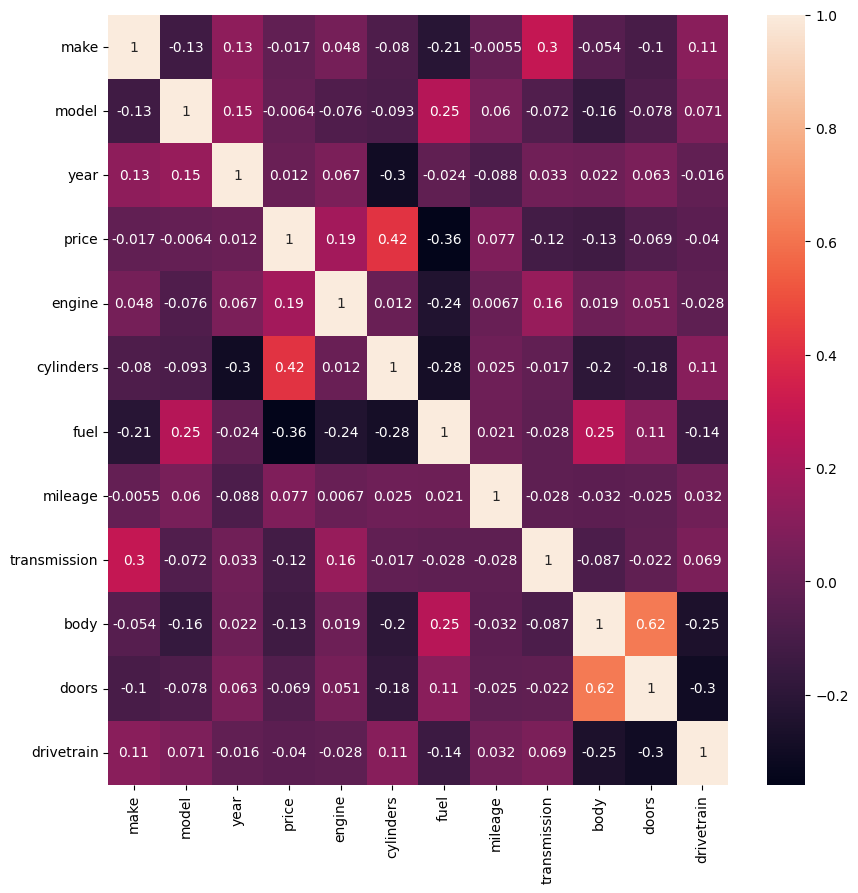

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

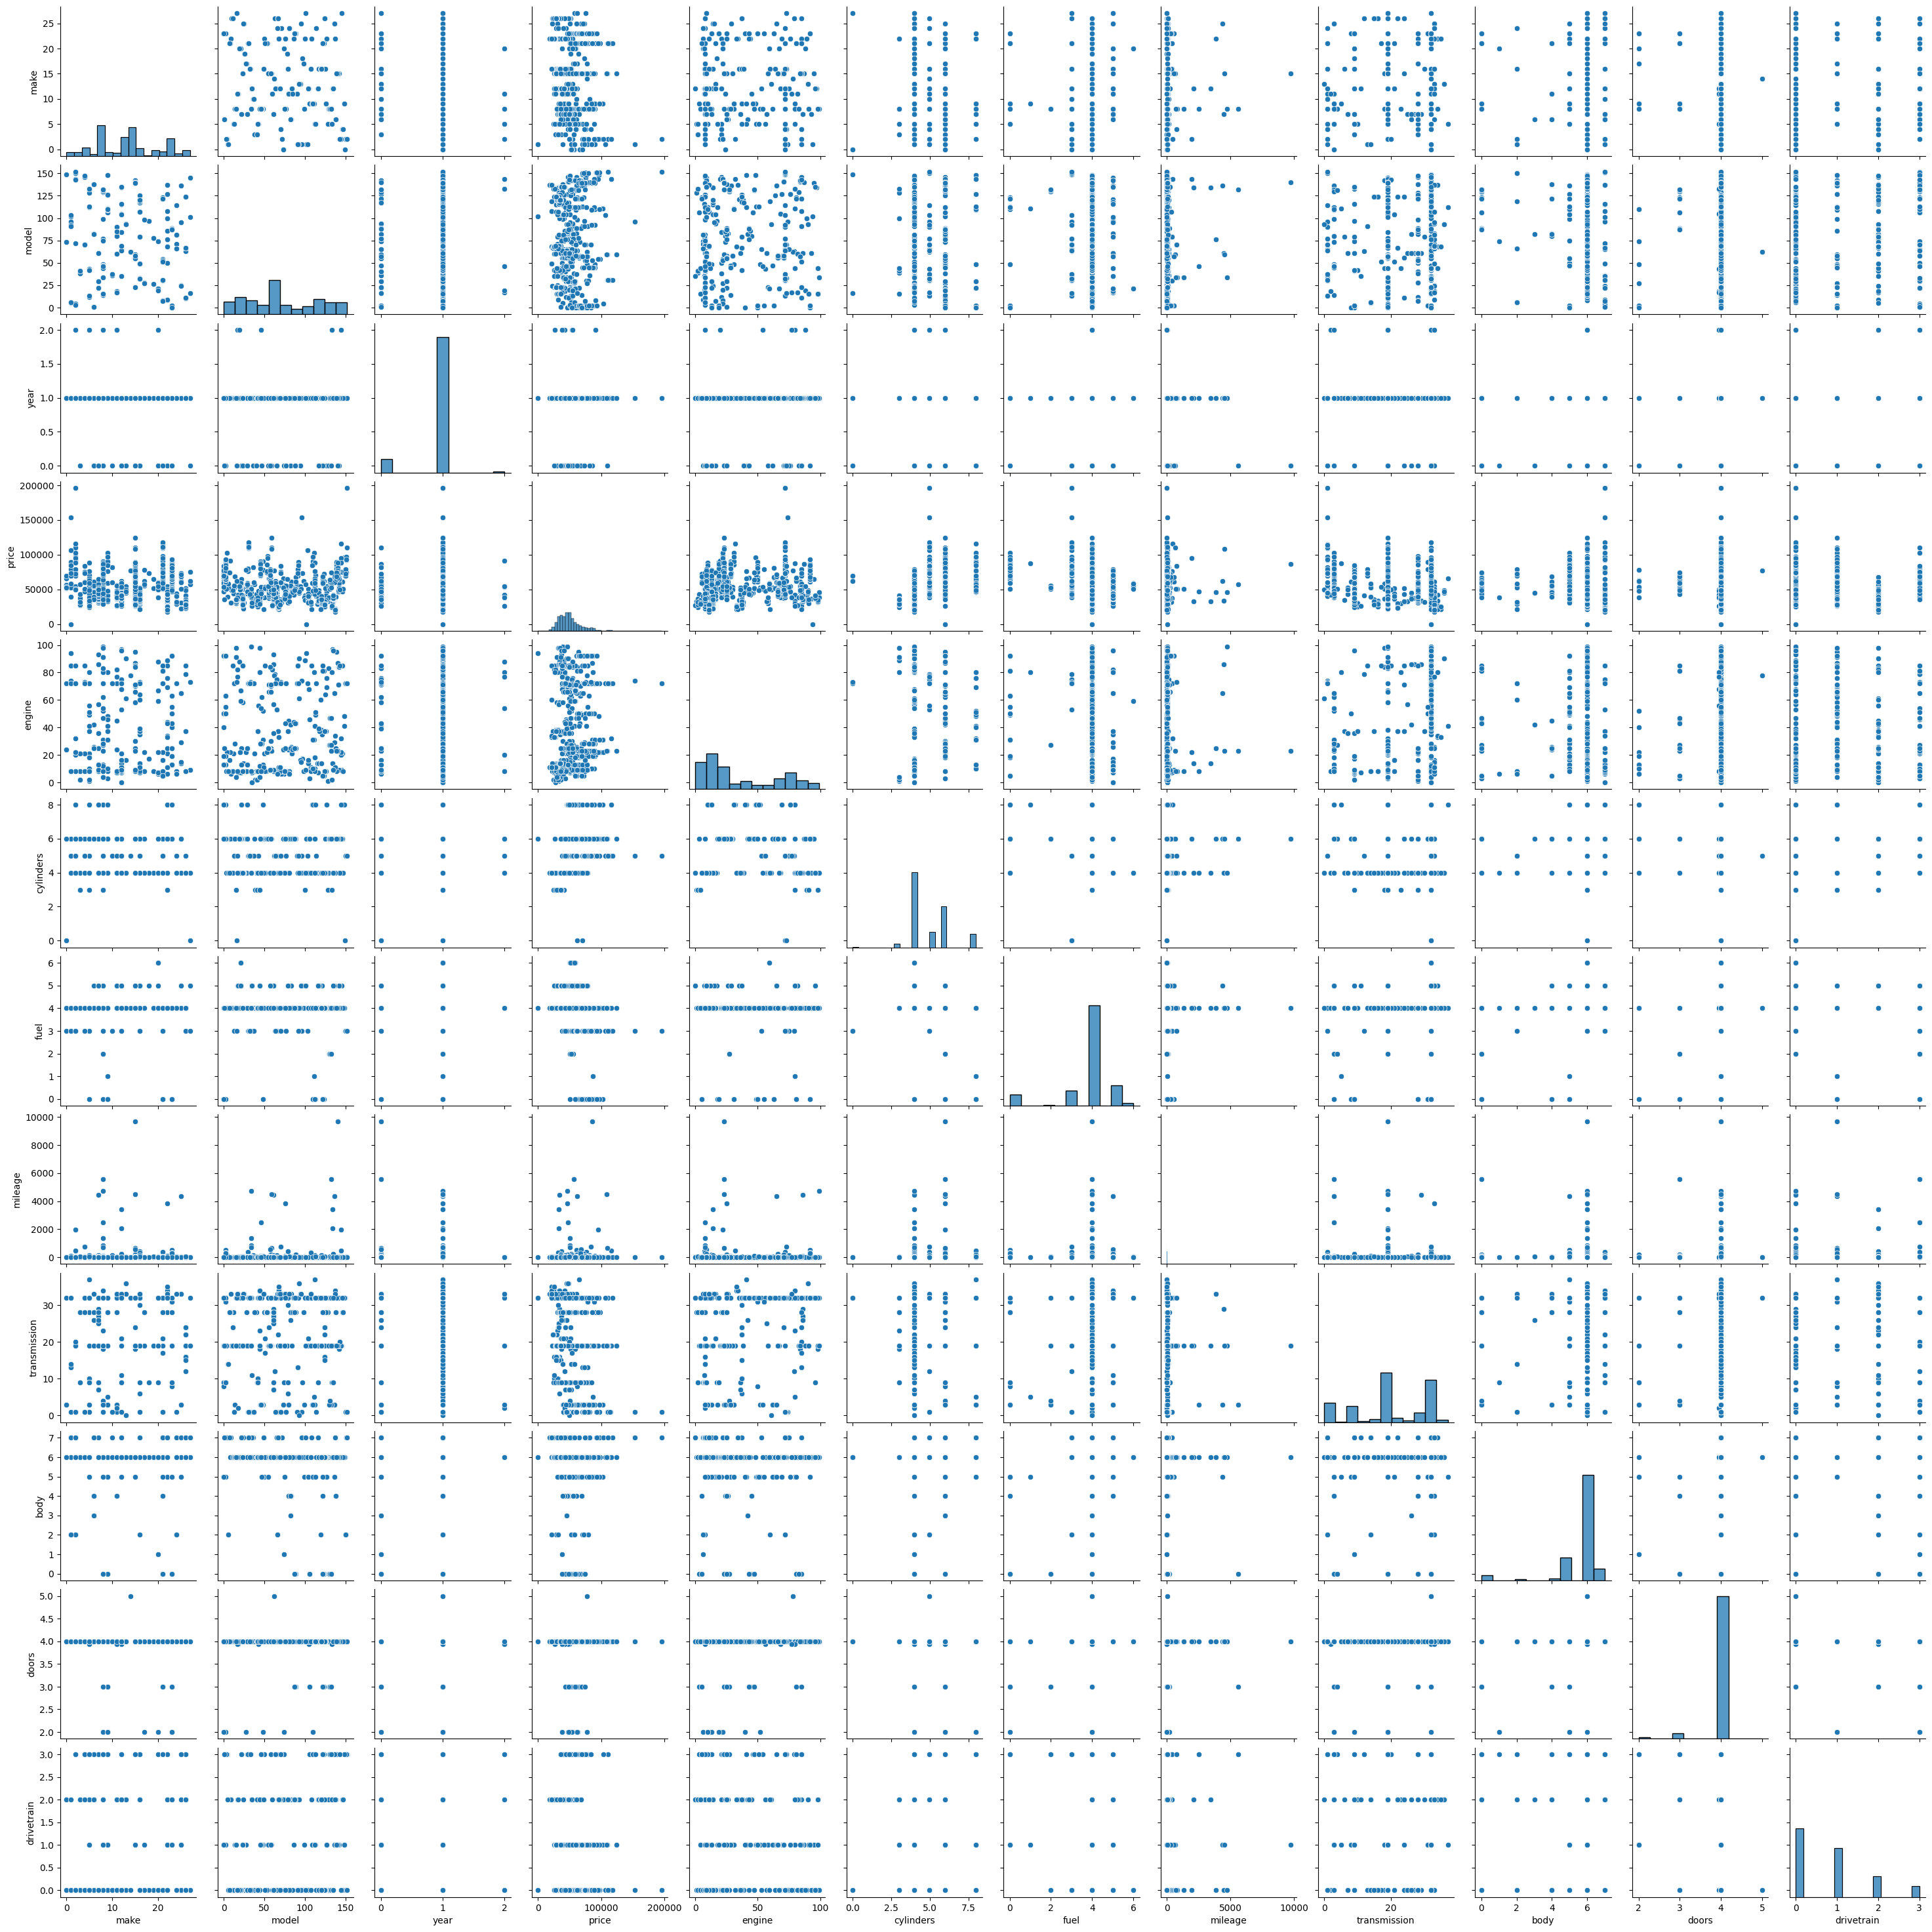

In [112]:
sns.pairplot(df)

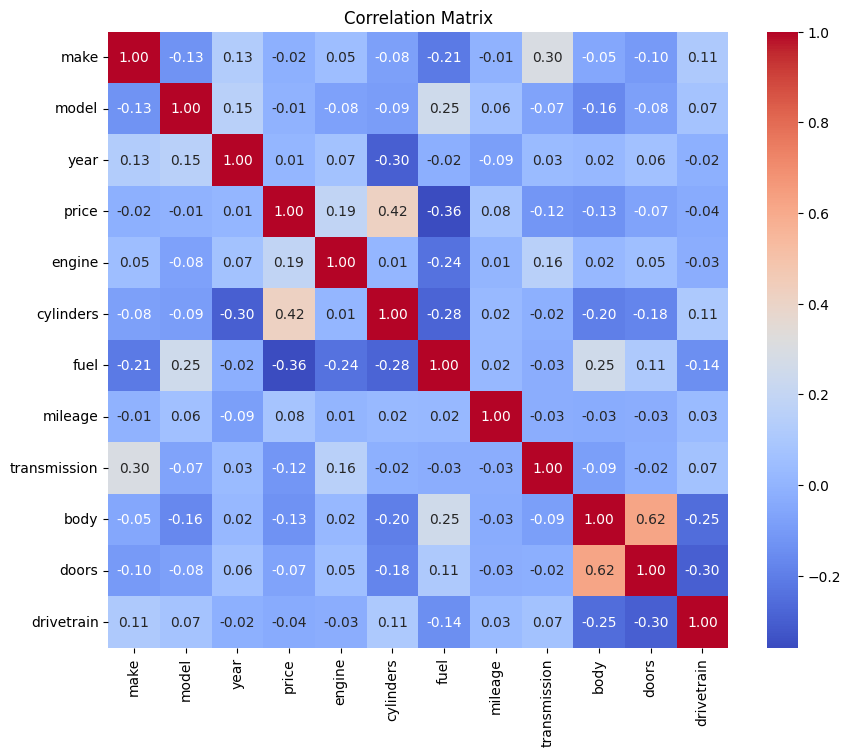

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Visualize as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import xgboost as xgb

In [116]:
def objective(trial):
    regressor_name = trial.suggest_categorical(
        'regressor',
        ['LinearRegression', 'SVR', 'RandomForestRegressor', 'GradientBoostingRegressor', 'XGBRegressor']
    )

    if regressor_name == 'LinearRegression':
        model = LinearRegression()

    elif regressor_name == 'SVR':
        svr_c = trial.suggest_float('svr_c', 1e-3, 1e3, log=True)
        epsilon = trial.suggest_float('epsilon', 1e-3, 1.0, log=True)
        kernel = trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'] + [1 / X_train.shape[1]])

        model = SVR(C=svr_c, epsilon=epsilon, kernel=kernel, gamma=gamma)

    elif regressor_name == 'RandomForestRegressor':
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 300),
            max_depth=trial.suggest_int('max_depth', 3, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            bootstrap=trial.suggest_categorical('bootstrap', [True, False]),
            random_state=42
        )

    elif regressor_name == 'GradientBoostingRegressor':
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 300),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            random_state=42
        )

    elif regressor_name == 'XGBRegressor':
        model = xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 300),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 30),
            min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            random_state=42
        )

    else:
        raise ValueError("Unsupported regressor")

    # Cross-validation with scoring = negative MSE (higher is better)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean()
    return score


In [117]:
!pip install optuna
import optuna
from optuna.visualization import plot_contour,plot_optimization_history,plot_parallel_coordinate,plot_slice,plot_param_importances

In [118]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=100)

[I 2025-07-25 14:03:12,352] A new study created in memory with name: no-name-0a5cdca6-effb-4e7c-8763-80979ef7a4bf
[I 2025-07-25 14:03:13,912] Trial 0 finished with value: -144171229.18955445 and parameters: {'regressor': 'RandomForestRegressor', 'n_estimators': 215, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 3, 'bootstrap': False}. Best is trial 0 with value: -144171229.18955445.
[I 2025-07-25 14:03:14,208] Trial 1 finished with value: -136706755.15435994 and parameters: {'regressor': 'GradientBoostingRegressor', 'n_estimators': 52, 'learning_rate': 0.027255935401857098, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 9}. Best is trial 1 with value: -136706755.15435994.
[I 2025-07-25 14:03:14,739] Trial 2 finished with value: -108507266.30940378 and parameters: {'regressor': 'XGBRegressor', 'n_estimators': 234, 'learning_rate': 0.0769189484133391, 'max_depth': 17, 'min_child_weight': 7, 'subsample': 0.5146148831701238, 'colsample_bytree': 0.7801824930577

In [119]:
best_trial = study.best_trial
print("Best trial:")
print(f"  Value: {best_trial.value}")
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value: -103492893.85513966
  Params: 
    regressor: XGBRegressor
    n_estimators: 250
    learning_rate: 0.02750993472689388
    max_depth: 12
    min_child_weight: 5
    subsample: 0.6941473902892425
    colsample_bytree: 0.7090887159747168


In [120]:
study.trials_dataframe()['params_regressor'].value_counts()

,count
params_regressor,
XGBRegressor,68
RandomForestRegressor,9
GradientBoostingRegressor,8
SVR,8
LinearRegression,7


In [121]:
plot_optimization_history(study)

In [122]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300,350,400],
    'learning_rate': [0.01, 0.025, 0.05,0.08],
    'max_depth': [4,5, 10, 15],
    'min_child_weight': [1, 2, 3],
    'subsample': [0.4,0.8, 0.9, 1.0],
    'colsample_bytree': [0.3, 0.5, 0.7],
}

# Initialize model
xgb_model = XGBRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # RMSE as scoring metric
    cv=3,  # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found:", grid_search.best_params_)

# Best score
print("Best RMSE (negative):", grid_search.best_score_)

Fitting 3 folds for each of 2880 candidates, totalling 8640 fits
Best parameters found: {'colsample_bytree': 0.3, 'learning_rate': 0.08, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}
Best RMSE (negative): -9514.392256637775


In [123]:
best_model = xgb.XGBRegressor(
    colsample_bytree=0.3,
    learning_rate=0.08,
    max_depth=5,
    min_child_weight=1,
    n_estimators=300,
    subsample=0.9,
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.08, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [124]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Test RMSE: 8062.034512999128


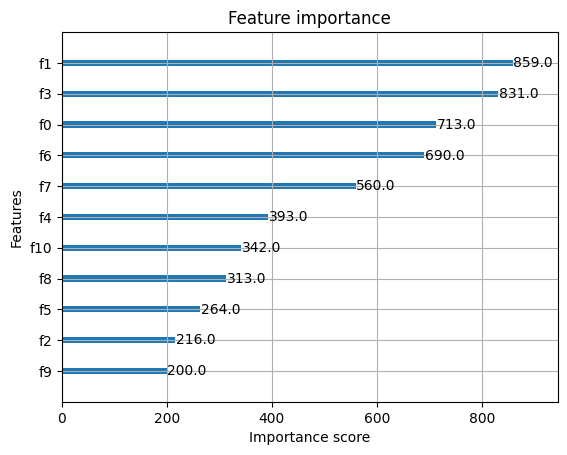

In [125]:
xgb.plot_importance(best_model)
plt.show()

In [126]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv('/content/dataset.csv')

df['description'] = df['description'].fillna('')
df['name'] = df['name'].fillna('')
df['model'] = df['model'].fillna('')

df['brand'] = df['name'].apply(lambda x: x.split()[0] if len(x.split()) > 0 else 'Unknown')
df['variant'] = df['model'].apply(lambda x: x.split()[-1] if len(x.split()) > 0 else 'Unknown')

tfidf = TfidfVectorizer(max_features=100)

desc_tfidf = tfidf.fit_transform(df['description']).toarray()
name_tfidf = tfidf.fit_transform(df['name']).toarray()
model_tfidf = tfidf.fit_transform(df['model']).toarray()

text_features = np.hstack([desc_tfidf, name_tfidf, model_tfidf])

label_cols = ['brand', 'variant']
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

onehot_cols = ['fuel', 'body', 'transmission', 'doors','engine']
df[onehot_cols] = df[onehot_cols].fillna('Unknown')
df = pd.get_dummies(df, columns=onehot_cols)

numeric_cols = ['price',  'cylinders', 'mileage']
knn_imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

X_structured = df[numeric_cols + label_cols + list(df.columns[df.columns.str.startswith(tuple(onehot_cols))])]
X_final = np.hstack([X_structured.values, text_features])

y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

model = XGBRegressor()
model.fit(X_train, y_train)


preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" Final RMSE: {rmse:.2f}")


 Final RMSE: 7841.10


In [127]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

xgb = XGBRegressor()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

voting = VotingRegressor([('xgb', xgb), ('rf', rf), ('gbr', gbr)])
voting.fit(X_train, y_train)
voting_preds = voting.predict(X_test)
voting_rmse = np.sqrt(mean_squared_error(y_test, voting_preds))
print(f" Voting Regressor RMSE: {voting_rmse:.2f}")


stacking = StackingRegressor(
    estimators=[('xgb', xgb), ('rf', rf), ('gbr', gbr)],
    final_estimator=Ridge()
)
stacking.fit(X_train, y_train)
stacking_preds = stacking.predict(X_test)
stacking_rmse = np.sqrt(mean_squared_error(y_test, stacking_preds))
print(f" Stacking Regressor RMSE: {stacking_rmse:.2f}")


 Voting Regressor RMSE: 543.96
 Stacking Regressor RMSE: 601.74


In [128]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression

# Base Models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Bagging
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)  # Boosting
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)  # Boosting
xgb_model = XGBRegressor(n_estimators=100, random_state=42)  # Boosting

meta_model = LinearRegression()

In [129]:
models = {
    "Random Forest (Bagging)": rf_model,
    "Gradient Boosting": gb_model,
    "AdaBoost": ada_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"✅ {name} RMSE: {rmse:.2f}")


✅ Random Forest (Bagging) RMSE: 783.95
✅ Gradient Boosting RMSE: 517.57
✅ AdaBoost RMSE: 1810.12
✅ XGBoost RMSE: 489.63


In [130]:
voting_model = VotingRegressor(estimators=[
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('gb', gb_model)
])

voting_model.fit(X_train, y_train)
voting_preds = voting_model.predict(X_test)
voting_rmse = np.sqrt(mean_squared_error(y_test, voting_preds))
print(f"✅ Voting Regressor RMSE: {voting_rmse:.2f}")

✅ Voting Regressor RMSE: 543.96


In [131]:
stacking_model = StackingRegressor(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', gb_model)
    ],
    final_estimator=meta_model,
    passthrough=True
)

stacking_model.fit(X_train, y_train)
stacking_preds = stacking_model.predict(X_test)
stacking_rmse = np.sqrt(mean_squared_error(y_test, stacking_preds))
print(f"✅ Stacking Regressor RMSE: {stacking_rmse:.2f}")


✅ Stacking Regressor RMSE: 0.00
